In [ ]:
import xarray
import pandas as pd
import numpy as np

import datetime

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates

import glob
from scipy.interpolate import RegularGridInterpolator

kk = 590
ee = 658



# Open HSRL file here.

In [ ]:
dat = '20191003'
base_date = pd.Timestamp('2019-10-03')
ds_nav = xarray.open_dataset(f'WWW-AIR_1726704979598/CAMP2EX-HSRL2_P3B_{dat}_R0.h5', engine='h5netcdf', 
                             phony_dims='access', group='Nav_Data')
base_jday = ds_nav['Jday'][:,0].values[0]
day_deltas = ds_nav['Jday'][:,0].values - base_jday
time_deltas = pd.to_timedelta(ds_nav['gps_time'][:,0].values, unit='h')
dates = base_date + pd.to_timedelta(day_deltas, unit='D')
date_times = dates + time_deltas
formatted_dates = date_times.strftime('%Y-%m-%d %H:%M:%S')

ds_nav['Date'] = xarray.DataArray(
    formatted_dates,
    dims=["time"]
)

df_nav = ds_nav['Date'].to_dataframe().reset_index()
df_nav['time'] = pd.to_datetime(df_nav['time'])

dat = '20191003'
dat1 = '2019-10-03-03600'
dat2 = '2019-10-04-03600'
workdir = 'WWW-AIR_1726704979598/'
p3file = f'CAMP2Ex-mrg01-P3B-NC_merge_{dat}_R3.nc'
p3data_ds = xarray.open_dataset(workdir+p3file)

variables = ['AOT532_hi', 'MLH']
selected_data = p3data_ds[variables]
p3data = selected_data.to_dataframe().reset_index()
p3data['time'] = pd.to_datetime(p3data['time'].dt.strftime("%Y-%m-%d %H:%M:%S"))

df_nav_ = pd.merge(df_nav, p3data, on='time', how='inner')

ds_one = xarray.open_dataset(f'WWW-AIR_1726704979598/CAMP2EX-HSRL2_P3B_{dat}_R0.h5', engine='h5netcdf', phony_dims='access', group='DataProducts')
variable_data = ds_one['532_ext']

# Open MUSICAv0 file here

In [3]:
def extract_level(df, lev):
    """
    Extract a single model level time series.
    lev: model level number (1–30)
    """
    return (
        df.loc[df['nl'] == (31 - lev), ['datetime', 'alt_mod']]
          .set_index('datetime')
          .to_xarray()
    )


In [ ]:
# ---------------------------------------------------------
# LOAD HSRL (OBS) FOR CONTROL COMPARISON
# ---------------------------------------------------------

file_pattern = 'curtain_tracks/hsrl_20191003_curtain_CAMP2Ex.nc'
file_list = glob.glob(file_pattern)

ds = xarray.open_mfdataset(file_list, combine='by_coords')
ds = ds.isel(Date=slice(kk, ee))

average_per_altitude = ds.mean(dim='Date')
std_per_altitude     = ds.std(dim='Date')

constant_altitudes_ctrl = ds.Altitude.values


# ---------------------------------------------------------
# LOAD CONTROL MODEL DATA
# ---------------------------------------------------------

file_list_ctrl = [
    "curtain_tracks/p3_2019-10-03-03600_day1_curtain_MUSICAv0_7km_CAMP2Ex.nc",
    "curtain_tracks/p3_2019-10-04-03600_day2_curtain_MUSICAv0_7km_CAMP2Ex.nc"
]

ds_mod_ctrl = xarray.open_mfdataset(file_list_ctrl, combine='by_coords')

common_dates_ctrl = np.intersect1d(ds['Date'], ds_mod_ctrl['datetime'].values)
ds_mod_ctrl = ds_mod_ctrl.sel(datetime=common_dates_ctrl)
ds_mod_ctrl['datetime'] = pd.to_datetime(ds_mod_ctrl['datetime'].values)

variables_ctrl = ['alt_mod', 'EXTINCT_mod', 'pblh_mod', 'u_mod', 'v_mod', 'w_mod']
ds_mod_ctrl = ds_mod_ctrl[variables_ctrl]

df_mod_ctrl = ds_mod_ctrl.to_dataframe().reset_index()
df_mod_ctrl['datetime'] = pd.to_datetime(df_mod_ctrl['datetime'])

df_mod_interp_ctrl = []
grouped_ctrl = df_mod_ctrl.groupby('datetime')

for name, group in grouped_ctrl:
    group_sorted = group.sort_values('alt_mod')

    min_alt = group_sorted['alt_mod'].min()
    max_alt = group_sorted['alt_mod'].max()

    valid_altitudes = constant_altitudes_ctrl[
        (constant_altitudes_ctrl >= min_alt) &
        (constant_altitudes_ctrl <= max_alt)
    ]

    extinct_interp = np.interp(valid_altitudes, group_sorted['alt_mod'], group_sorted['EXTINCT_mod'])
    u_interp       = np.interp(valid_altitudes, group_sorted['alt_mod'], group_sorted['u_mod'])
    v_interp       = np.interp(valid_altitudes, group_sorted['alt_mod'], group_sorted['v_mod'])
    w_interp       = np.interp(valid_altitudes, group_sorted['alt_mod'], group_sorted['w_mod'])

    interpolated_df = pd.DataFrame({
        'datetime': name,
        'altitude': valid_altitudes,
        'EXTINCT_mod': extinct_interp,
        'u_mod': u_interp,
        'v_mod': v_interp,
        'w_mod': w_interp
    })

    df_mod_interp_ctrl.append(interpolated_df)

df_mod_interp_ctrl = pd.concat(df_mod_interp_ctrl, ignore_index=True)

grouped_mean_ctrl = df_mod_interp_ctrl.groupby('altitude').mean().reset_index()
grouped_std_ctrl  = df_mod_interp_ctrl.groupby('altitude').std().reset_index()

u_vals_ctrl = df_mod_interp_ctrl.pivot(
    index='datetime', columns='altitude', values='u_mod'
).values

v_vals_ctrl = df_mod_interp_ctrl.pivot(
    index='datetime', columns='altitude', values='v_mod'
).values

w_vals_ctrl = df_mod_interp_ctrl.pivot(
    index='datetime', columns='altitude', values='w_mod'
).values

time_vals_mod_ctrl = df_mod_interp_ctrl['datetime'].unique()
alt_vals_mod_ctrl  = df_mod_interp_ctrl['altitude'].unique()

df_u_ctrl = df_mod_interp_ctrl.pivot_table(
    index='datetime',
    columns='altitude',
    values='u_mod',
    aggfunc='mean'
).sort_index(axis=1)

df_v_ctrl = df_mod_interp_ctrl.pivot_table(
    index='datetime',
    columns='altitude',
    values='v_mod',
    aggfunc='mean'
).sort_index(axis=1)

df_w_ctrl = df_mod_interp_ctrl.pivot_table(
    index='datetime',
    columns='altitude',
    values='w_mod',
    aggfunc='mean'
).sort_index(axis=1)

df_mod_pblh_ctrl = df_mod_ctrl[['datetime','pblh_mod']].drop_duplicates()
ds_mod_pblh_interp_ctrl = df_mod_pblh_ctrl.set_index(['datetime']).to_xarray()

ds_mod_interp_ctrl = df_mod_interp_ctrl.set_index(['datetime', 'altitude']).to_xarray()
curt_time_ctrl = ds_mod_interp_ctrl['datetime']
curt_time_np_ctrl = np.array(curt_time_ctrl, dtype='datetime64')
curt_time2_ctrl = np.tile(
    curt_time_np_ctrl[:, np.newaxis],
    (1, ds_mod_interp_ctrl['EXTINCT_mod'].shape[1])
)

ds_mod_all_ctrl = df_mod_ctrl.set_index(['datetime', 'alt_mod']).to_xarray()

startdate_ctrl = '2019-10-04 00:36:59'
enddate_ctrl   = '2019-10-04 00:53:29'
filedate_ctrl  = '1004_0036'

ds_mod_interp__ctrl = ds_mod_interp_ctrl.sel(datetime=slice(startdate_ctrl, enddate_ctrl))
ds_mod_all__ctrl    = ds_mod_all_ctrl.sel(datetime=slice(startdate_ctrl, enddate_ctrl))

levels_to_plot_ctrl = range(15, 31)

ds_levels_ctrl = {
    lev: extract_level(df_mod_ctrl, lev).sel(datetime=slice(startdate_ctrl, enddate_ctrl))
    for lev in levels_to_plot_ctrl
}

ds_mod_pblh_interp__ctrl = ds_mod_pblh_interp_ctrl.sel(datetime=slice(startdate_ctrl, enddate_ctrl))

# ---------------------------------------------------------
# WIND VECTORS
# ---------------------------------------------------------

model_times_ctrl = df_u_ctrl.index.values
altitudes_m_ctrl = df_u_ctrl.columns.values / 1000.0

u_matrix_ctrl = df_u_ctrl.values
v_matrix_ctrl = df_v_ctrl.values
w_matrix_ctrl = df_w_ctrl.values

t_step_ctrl = 5
z_step_ctrl = 6

u_mod_dec_ctrl = u_matrix_ctrl[::t_step_ctrl, ::z_step_ctrl]
v_mod_dec_ctrl = v_matrix_ctrl[::t_step_ctrl, ::z_step_ctrl]
w_mod_dec_ctrl = w_matrix_ctrl[::t_step_ctrl, ::z_step_ctrl]

time_mod_dec_ctrl = model_times_ctrl[::t_step_ctrl]
alt_mod_dec_ctrl  = altitudes_m_ctrl[::z_step_ctrl]

Tmod_ctrl, Zmod_ctrl = np.meshgrid(time_mod_dec_ctrl, alt_mod_dec_ctrl, indexing='ij')

/tmp/ipykernel_1702197/1562133444.py:76: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_mean_ctrl = df_mod_interp_ctrl.groupby('altitude').mean().reset_index()
/tmp/ipykernel_1702197/1562133444.py:77: FutureWarning: The default value of numeric_only in DataFrameGroupBy.std is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_std_ctrl  = df_mod_interp_ctrl.groupby('altitude').std().reset_index()


In [ ]:
# ---------------------------------------------------------
# LOAD EXP01
# ---------------------------------------------------------

file_list_exp01 = [
    "curtain_tracks_Exp01/p3_2019-10-03-03600_day1_curtain_MUSICAv0_7km_CAMP2Ex.nc",
    "curtain_tracks_Exp01/p3_2019-10-04-03600_day2_curtain_MUSICAv0_7km_CAMP2Ex.nc"
]

ds_mod_exp01 = xarray.open_mfdataset(file_list_exp01, combine='by_coords')

common_dates_exp01 = np.intersect1d(ds['Date'], ds_mod_exp01['datetime'].values)
ds_mod_exp01 = ds_mod_exp01.sel(datetime=common_dates_exp01)
ds_mod_exp01['datetime'] = pd.to_datetime(ds_mod_exp01['datetime'].values)

variables_exp01 = ['alt_mod', 'EXTINCT_mod', 'pblh_mod', 'u_mod', 'v_mod', 'w_mod']
ds_mod_exp01 = ds_mod_exp01[variables_exp01]

df_mod_exp01 = ds_mod_exp01.to_dataframe().reset_index()
df_mod_exp01['datetime'] = pd.to_datetime(df_mod_exp01['datetime'])

constant_altitudes_exp01 = ds.Altitude.values

df_mod_interp_exp01 = []
grouped_exp01 = df_mod_exp01.groupby('datetime')

for name, group in grouped_exp01:
    group_sorted = group.sort_values('alt_mod')

    min_alt = group_sorted['alt_mod'].min()
    max_alt = group_sorted['alt_mod'].max()

    valid_altitudes = constant_altitudes_exp01[
        (constant_altitudes_exp01 >= min_alt) &
        (constant_altitudes_exp01 <= max_alt)
    ]

    extinct_interp = np.interp(valid_altitudes, group_sorted['alt_mod'], group_sorted['EXTINCT_mod'])
    u_interp       = np.interp(valid_altitudes, group_sorted['alt_mod'], group_sorted['u_mod'])
    v_interp       = np.interp(valid_altitudes, group_sorted['alt_mod'], group_sorted['v_mod'])
    w_interp       = np.interp(valid_altitudes, group_sorted['alt_mod'], group_sorted['w_mod'])

    interpolated_df = pd.DataFrame({
        'datetime': name,
        'altitude': valid_altitudes,
        'EXTINCT_mod': extinct_interp,
        'u_mod': u_interp,
        'v_mod': v_interp,
        'w_mod': w_interp
    })

    df_mod_interp_exp01.append(interpolated_df)

df_mod_interp_exp01 = pd.concat(df_mod_interp_exp01, ignore_index=True)

grouped_mean_exp01 = df_mod_interp_exp01.groupby('altitude').mean().reset_index()
grouped_std_exp01  = df_mod_interp_exp01.groupby('altitude').std().reset_index()

u_vals_exp01 = df_mod_interp_exp01.pivot(index='datetime', columns='altitude', values='u_mod').values
v_vals_exp01 = df_mod_interp_exp01.pivot(index='datetime', columns='altitude', values='v_mod').values
w_vals_exp01 = df_mod_interp_exp01.pivot(index='datetime', columns='altitude', values='w_mod').values

time_vals_mod_exp01 = df_mod_interp_exp01['datetime'].unique()
alt_vals_mod_exp01  = df_mod_interp_exp01['altitude'].unique()

df_u_exp01 = df_mod_interp_exp01.pivot_table(
    index='datetime', columns='altitude', values='u_mod', aggfunc='mean'
).sort_index(axis=1)

df_v_exp01 = df_mod_interp_exp01.pivot_table(
    index='datetime', columns='altitude', values='v_mod', aggfunc='mean'
).sort_index(axis=1)

df_w_exp01 = df_mod_interp_exp01.pivot_table(
    index='datetime', columns='altitude', values='w_mod', aggfunc='mean'
).sort_index(axis=1)

df_mod_pblh_exp01 = df_mod_exp01[['datetime', 'pblh_mod']].drop_duplicates()
ds_mod_pblh_interp_exp01 = df_mod_pblh_exp01.set_index(['datetime']).to_xarray()

ds_mod_interp_exp01 = df_mod_interp_exp01.set_index(['datetime', 'altitude']).to_xarray()

curt_time_exp01 = ds_mod_interp_exp01['datetime']
curt_time_np_exp01 = np.array(curt_time_exp01, dtype='datetime64')
curt_time2_exp01 = np.tile(
    curt_time_np_exp01[:, np.newaxis],
    (1, ds_mod_interp_exp01['EXTINCT_mod'].shape[1])
)

ds_mod_all_exp01 = df_mod_exp01.set_index(['datetime', 'alt_mod']).to_xarray()

startdate_exp01 = '2019-10-04 00:36:59'
enddate_exp01   = '2019-10-04 00:53:29'
filedate_exp01  = '1004_0036'

ds_mod_interp__exp01 = ds_mod_interp_exp01.sel(datetime=slice(startdate_exp01, enddate_exp01))
ds_mod_all__exp01    = ds_mod_all_exp01.sel(datetime=slice(startdate_exp01, enddate_exp01))

levels_to_plot_exp01 = range(15, 31)

ds_levels_exp01 = {
    lev: extract_level(df_mod_exp01, lev).sel(datetime=slice(startdate_exp01, enddate_exp01))
    for lev in levels_to_plot_exp01
}

ds_mod_pblh_interp__exp01 = ds_mod_pblh_interp_exp01.sel(datetime=slice(startdate_exp01, enddate_exp01))

# ---------------------------------------------------------
# WIND VECTORS
# ---------------------------------------------------------

model_times_exp01 = df_u_exp01.index.values
altitudes_m_exp01 = df_u_exp01.columns.values / 1000.0

u_matrix_exp01 = df_u_exp01.values
v_matrix_exp01 = df_v_exp01.values
w_matrix_exp01 = df_w_exp01.values

t_step_exp01 = 5
z_step_exp01 = 6

u_mod_dec_exp01 = u_matrix_exp01[::t_step_exp01, ::z_step_exp01]
v_mod_dec_exp01 = v_matrix_exp01[::t_step_exp01, ::z_step_exp01]
w_mod_dec_exp01 = w_matrix_exp01[::t_step_exp01, ::z_step_exp01]

time_mod_dec_exp01 = model_times_exp01[::t_step_exp01]
alt_mod_dec_exp01  = altitudes_m_exp01[::z_step_exp01]

Tmod_exp01, Zmod_exp01 = np.meshgrid(time_mod_dec_exp01, alt_mod_dec_exp01, indexing='ij')


/tmp/ipykernel_1702197/2100005352.py:60: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_mean_exp01 = df_mod_interp_exp01.groupby('altitude').mean().reset_index()
/tmp/ipykernel_1702197/2100005352.py:61: FutureWarning: The default value of numeric_only in DataFrameGroupBy.std is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_std_exp01  = df_mod_interp_exp01.groupby('altitude').std().reset_index()


/tmp/ipykernel_1702197/1397809788.py:297: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


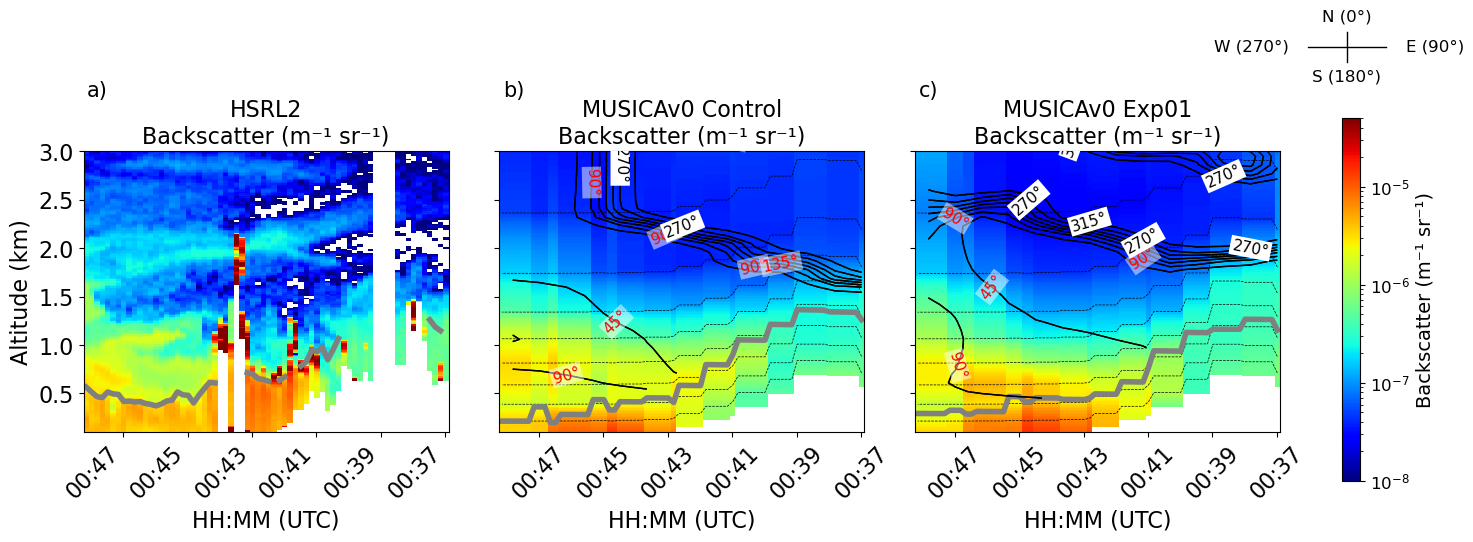

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter

date_index = pd.DatetimeIndex(ds_nav['Date'][kk:ee].values)
lon_vals   = df_nav_['lon'].values[kk:ee]
mlh_vals   = df_nav_['MLH'].values[kk:ee]
time_vals  = df_nav_['time'].values[kk:ee]

tick_indices  = np.linspace(0, len(date_index) - 1, num=12, dtype=int)
tick_positions = date_index[tick_indices]
tick_labels    = [f"{lon_vals[i]:.2f}" for i in tick_indices]

fig, (ax0, ax1, ax2) = plt.subplots(
    1, 3, figsize=(13, 5), sharey=True,
    gridspec_kw={"width_ratios": [1, 1, 1]}
)
fig.subplots_adjust(wspace=0.15)

# =========================================================
# PANEL (a) — HSRL2
# =========================================================
ax0.text(0.01, 1.18, "a)", transform=ax0.transAxes,
         fontsize=15, va="bottom", ha="left")
c0 = ax0.pcolormesh(
    date_index,
    ds_one['Altitude'][0, :].values / 1000,
    ds_one['532_bsc'][kk:ee, :].T / 1000,
    norm=mcolors.LogNorm(vmin=1E-8, vmax=0.5E-4),
    cmap="jet"
)

ax0.plot(time_vals, mlh_vals/1000, color='gray', linewidth=4)

ax0.xaxis.set_major_locator(mdates.MinuteLocator(interval=2))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

for label in ax0.xaxis.get_majorticklabels():
    label.set_horizontalalignment('right')

ax0.set_xlabel("HH:MM (UTC)", fontsize=16)
ax0.set_title("HSRL2\nBackscatter (m⁻¹ sr⁻¹)", fontsize=16)
ax0.set_ylim(0.1, 3)
ax0.tick_params(axis='y', labelsize=16)
ax0.tick_params(axis='x', labelsize=16, rotation=45)
ax0.set_ylabel("Altitude (km)", fontsize=16)

ax0.invert_xaxis()

# =========================================================
# PANEL (b) — MUSICAv0 Control
# =========================================================
ax1.text(0.01, 1.18, "b)", transform=ax1.transAxes,
         fontsize=15, va="bottom", ha="left")

c1 = ax1.pcolormesh(
    ds_mod_interp__ctrl['datetime'],
    ds_mod_interp__ctrl['altitude'] / 1000,
    (ds_mod_interp__ctrl['EXTINCT_mod'] / 65.74).T,
    norm=mcolors.LogNorm(vmin=1E-8, vmax=0.5E-4),
    cmap="jet"
)

for lev, ds_lev in ds_levels_ctrl.items():
    ax1.plot(ds_lev['datetime'], ds_lev['alt_mod']/1000,
             linewidth=0.5, linestyle='--', color='k')

ax1.plot(ds_mod_pblh_interp__ctrl['datetime'],
         ds_mod_pblh_interp__ctrl['pblh_mod']/1000,
         color='gray', linewidth=4)

# ---------------------------------------------------------
# METEOROLOGICAL WIND DIRECTION
# ---------------------------------------------------------
theta_math_ctrl = np.degrees(np.arctan2(v_mod_dec_ctrl, u_mod_dec_ctrl))
wind_dir_ctrl_raw = (270 - theta_math_ctrl) % 360
wind_dir_ctrl = gaussian_filter(wind_dir_ctrl_raw, sigma=0.8)

z_thresh = 3  # km

wind_dir_ctrl_low = np.where(Zmod_ctrl <= z_thresh, wind_dir_ctrl, np.nan)

levels_coarse = np.arange(0, 361, 45)
levels_fine   = np.arange(0, 361, 45)

ax1.contour(Tmod_ctrl, Zmod_ctrl, wind_dir_ctrl, levels=levels_coarse, colors='k', linewidths=1.0)
fine_contours_ctrl = ax1.contour(Tmod_ctrl, Zmod_ctrl, wind_dir_ctrl_low, levels=levels_fine, colors='k', linewidths=1.0)

label_mask_east_ctrl = np.where(
    (wind_dir_ctrl > 0) & (wind_dir_ctrl < 180),
    wind_dir_ctrl,
    np.nan
)

label_mask_west_ctrl = np.where(
    (wind_dir_ctrl >= 180) | (wind_dir_ctrl == 0),
    wind_dir_ctrl,
    np.nan
)

fine_labels_east_ctrl = ax1.contour(
    Tmod_ctrl, Zmod_ctrl, label_mask_east_ctrl,
    levels=levels_fine, colors='none'
)

texts_east_ctrl = ax1.clabel(
    fine_labels_east_ctrl,
    levels=levels_fine[::1],
    fmt='%d°',
    fontsize=11,
    colors='red'
)

for t in texts_east_ctrl:
    t.set_bbox(dict(facecolor=(1, 1, 1, 0.5), edgecolor='none', pad=1.5))

fine_labels_west_ctrl = ax1.contour(
    Tmod_ctrl, Zmod_ctrl, label_mask_west_ctrl,
    levels=levels_fine, colors='none'
)

texts_west_ctrl = ax1.clabel(
    fine_labels_west_ctrl,
    levels=levels_fine[::1],
    fmt='%d°',
    fontsize=11,
    colors='black'
)

for t in texts_west_ctrl:
    t.set_bbox(dict(facecolor='white', edgecolor='none', pad=1.5))

ax1.set_title("MUSICAv0 Control\nBackscatter (m⁻¹ sr⁻¹)", fontsize=16)
ax1.set_ylim(0.1, 3)
ax1.xaxis.set_major_locator(mdates.MinuteLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.set_xlabel("HH:MM (UTC)", fontsize=16)
ax1.tick_params(axis='x', labelsize=16, rotation=45)
ax1.invert_xaxis()

# =========================================================
# PANEL (c) — MUSICAv0 Exp01
# =========================================================
ax2.text(0.01, 1.18, "c)", transform=ax2.transAxes,
         fontsize=15, va="bottom", ha="left")

c2 = ax2.pcolormesh(
    ds_mod_interp__exp01['datetime'],
    ds_mod_interp__exp01['altitude'] / 1000,
    (ds_mod_interp__exp01['EXTINCT_mod'] / 65.74).T,
    norm=mcolors.LogNorm(vmin=1E-8, vmax=0.5E-4),
    cmap="jet"
)

for lev, ds_lev in ds_levels_exp01.items():
    ax2.plot(ds_lev['datetime'], ds_lev['alt_mod']/1000,
             linewidth=0.5, linestyle='--', color='k')

ax2.plot(ds_mod_pblh_interp__exp01['datetime'],
         ds_mod_pblh_interp__exp01['pblh_mod']/1000,
         color='gray', linewidth=4)

# ---------------------------------------------------------
# METEOROLOGICAL WIND DIRECTION
# ---------------------------------------------------------
theta_math_exp01 = np.degrees(np.arctan2(v_mod_dec_exp01, u_mod_dec_exp01))
wind_dir_exp01_raw = (270 - theta_math_exp01) % 360
wind_dir_exp01 = gaussian_filter(wind_dir_exp01_raw, sigma=0.8)

wind_dir_exp01_low = np.where(Zmod_exp01 <= z_thresh, wind_dir_exp01, np.nan)

ax2.contour(Tmod_exp01, Zmod_exp01, wind_dir_exp01, levels=levels_coarse, colors='k', linewidths=1.0)
fine_contours_exp01 = ax2.contour(Tmod_exp01, Zmod_exp01, wind_dir_exp01_low, levels=levels_fine, colors='k', linewidths=1.0)

label_mask_east_exp01 = np.where(
    (wind_dir_exp01 > 0) & (wind_dir_exp01 < 180),
    wind_dir_exp01,
    np.nan
)

label_mask_west_exp01 = np.where(
    (wind_dir_exp01 >= 180) | (wind_dir_exp01 == 0),
    wind_dir_exp01,
    np.nan
)

fine_labels_east_exp01 = ax2.contour(
    Tmod_exp01, Zmod_exp01, label_mask_east_exp01,
    levels=levels_fine, colors='none'
)

texts_east_exp01 = ax2.clabel(
    fine_labels_east_exp01,
    levels=levels_fine[::1],
    fmt='%d°',
    fontsize=11,
    colors='red'
)

for t in texts_east_exp01:
    t.set_bbox(dict(facecolor=(1, 1, 1, 0.5), edgecolor='none', pad=1.5))

fine_labels_west_exp01 = ax2.contour(
    Tmod_exp01, Zmod_exp01, label_mask_west_exp01,
    levels=levels_fine, colors='none'
)

texts_west_exp01 = ax2.clabel(
    fine_labels_west_exp01,
    levels=levels_fine[::1],
    fmt='%d°',
    fontsize=11,
    colors='black'
)

for t in texts_west_exp01:
    t.set_bbox(dict(facecolor='white', edgecolor='none', pad=1.5))

ax2.set_title("MUSICAv0 Exp01\nBackscatter (m⁻¹ sr⁻¹)", fontsize=16)
ax2.set_ylim(0.1, 3)
ax2.xaxis.set_major_locator(mdates.MinuteLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax2.set_xlabel("HH:MM (UTC)", fontsize=16)
ax2.tick_params(axis='x', labelsize=16, rotation=45)
ax2.invert_xaxis()

cbar = fig.colorbar(c2, ax=[ax0, ax1, ax2], fraction=0.018, pad=0.04)

pos = cbar.ax.get_position()
cbar.ax.set_position([pos.x0 + 0.15, pos.y0, pos.width, pos.height])

cbar.set_label("Backscatter (m⁻¹ sr⁻¹)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

compass_x = 1.04   # near right edge of figure
compass_y = 1.   # slightly above bottom

# Draw cross lines
fig.lines.append(plt.Line2D(
    [compass_x, compass_x], [compass_y - 0.03, compass_y + 0.03],
    transform=fig.transFigure, color='black', linewidth=1
))
fig.lines.append(plt.Line2D(
    [compass_x - 0.03, compass_x + 0.03], [compass_y, compass_y],
    transform=fig.transFigure, color='black', linewidth=1
))

fig.text(compass_x, compass_y + 0.045, "N (0°)",
         ha='center', va='bottom', fontsize=12)

fig.text(compass_x + 0.045, compass_y, "E (90°)",
         ha='left', va='center', fontsize=12)

fig.text(compass_x, compass_y - 0.045, "S (180°)",
         ha='center', va='top', fontsize=12)

fig.text(compass_x - 0.045, compass_y, "W (270°)",
         ha='right', va='center', fontsize=12)

plt.tight_layout()
plt.savefig("output/img/Figure14_AMSPaper.png",
            dpi=300, bbox_inches="tight")
